In [2]:
from domain.correlation.cpa_correlation import CpaCorrelation
from domain.correlation.cpa_service import CorrelationTask
from domain.key_scheduler import AesKeyScheduler
from domain.value_object import RangeParameters, Range, KeyByteGuesses
from infrastructure.h5_trace_repository import H5TraceRepository
from ui.correlation_plotter import CorrelationPlotter
from ui.key_rank_visualizer import KeyRankVisualizer
from domain.value_object import DataSource

total trace count: 100
total sample count: 14502


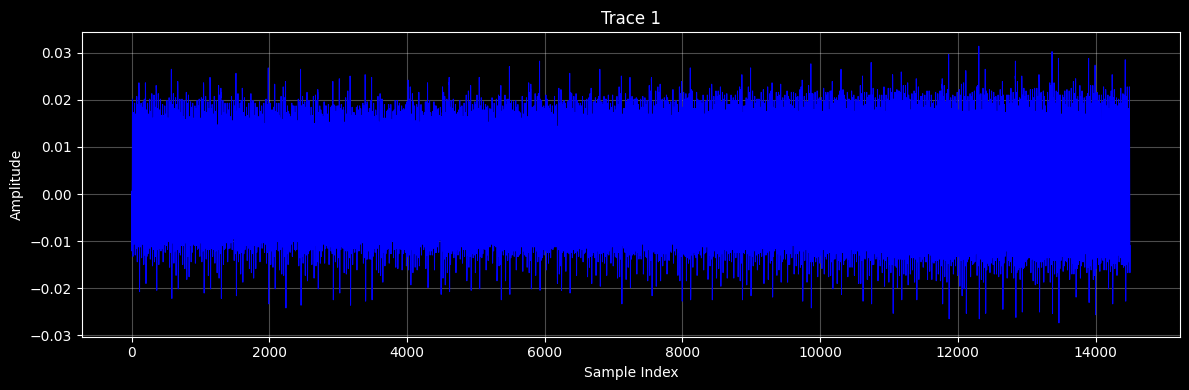

In [22]:
from ui.trace_plotter import TracePlotter

file_path = r"/home/aknay/github/defconsg-2026-nice-lab/project_file/project_file.sx"

with H5TraceRepository(file_path) as trace_repo:
    print("total trace count:", trace_repo.total_trace_count)
    print("total sample count:", trace_repo.total_sample_count)

    trace_plotter = TracePlotter(trace_repo)
    trace_plotter.plot_single(index=1)

In [23]:
from domain.leakage.leakage import InvSboxOutputLeakageModel

with H5TraceRepository(file_path) as trace_repo:
    range_parameter = RangeParameters(
        trace_range=Range(0, trace_repo.total_trace_count),
        trace_sample_range=Range(0, trace_repo.total_sample_count),
    )

    leakage_model = InvSboxOutputLeakageModel()

    results = []
    for i in range(16):
        correlation = CpaCorrelation()
        key_byte_guesses = KeyByteGuesses.from_full256_range()
        result = CorrelationTask(
            byte_location=i,
            range_parameters=range_parameter,
            leakage_model=leakage_model,
            correlation=correlation,
            trace_repository=trace_repo,
            data_source=DataSource.PLAINTEXT,
            key_byte_guesses=key_byte_guesses
        ).run()
        results.append(result)


In [24]:
visualizer = KeyRankVisualizer(results)

# 2. Display the table
# This will show the top 5 candidates for every byte
visualizer.display_rank_table(top_n=5)

# 3. Print the final guessed key hex string
guessed_key = visualizer.get_full_key_guess()
print(f"Guessed Key: {guessed_key.hex().upper()}")

,Byte 00,Byte 01,Byte 02,Byte 03,Byte 04,Byte 05,Byte 06,Byte 07,Byte 08,Byte 09,Byte 10,Byte 11,Byte 12,Byte 13,Byte 14,Byte 15
Rank 1,19 (0.598),7D (0.671),D6 (0.686),9D (0.660),90 (0.612),2A (0.653),88 (0.615),D6 (0.648),04 (0.515),47 (0.599),D2 (0.605),14 (0.630),05 (0.619),FC (0.581),37 (0.630),4C (0.611)
Rank 2,B5 (0.490),4F (0.467),E2 (0.486),36 (0.487),22 (0.456),98 (0.467),E4 (0.465),2D (0.530),A2 (0.476),70 (0.475),91 (0.474),2F (0.539),04 (0.471),AB (0.510),3C (0.465),FC (0.444)
Rank 3,12 (0.453),A4 (0.460),D5 (0.444),12 (0.455),B3 (0.443),29 (0.446),0B (0.455),37 (0.472),2A (0.468),83 (0.467),1C (0.459),4A (0.474),F3 (0.442),08 (0.486),60 (0.464),0B (0.441)
Rank 4,AB (0.447),18 (0.455),1F (0.442),D4 (0.453),3C (0.430),15 (0.442),26 (0.445),11 (0.446),BA (0.448),1C (0.438),F8 (0.454),C6 (0.453),99 (0.442),7D (0.471),00 (0.445),07 (0.425)
Rank 5,8E (0.427),66 (0.450),39 (0.430),95 (0.437),4D (0.430),0A (0.436),23 (0.436),9A (0.444),69 (0.446),03 (0.435),32 (0.440),A5 (0.451),FC (0.434),C3 (0.471),4E (0.444),4B (0.420)


Guessed Key: 197DD69D902A88D60447D21405FC374C


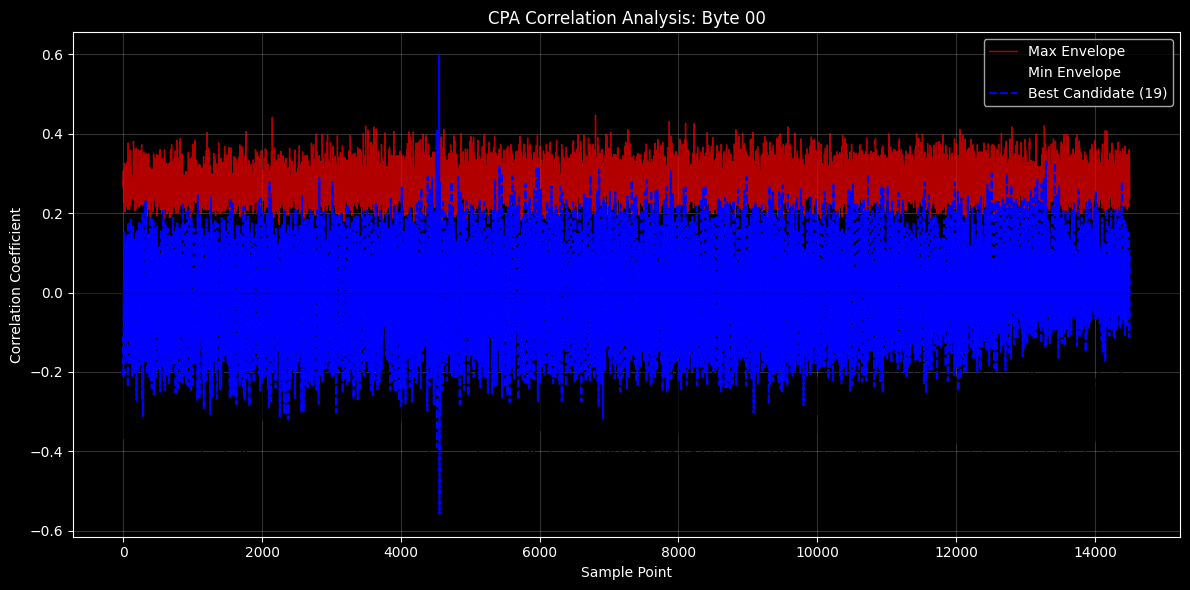

In [25]:
plotter = CorrelationPlotter(results)
plotter.plot(0)

In [28]:
scheduler = AesKeyScheduler(initial_round=10, desired_round=0, key=guessed_key)
result = scheduler.schedule()
text_result = result.decode('utf-8', errors='ignore')
print(text_result)

1234567890123456
